#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package to navigate through files and folders
import os

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
import opentnsim.fis as fis
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart

# import of modules important for locking
from opentnsim.lock import lock as lock_module
from opentnsim.vessel_traffic_service import vessel_traffic_service as vessel_traffic_service_module

# package(s) needed for inspecting the output
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# package(s) needed for inspecting the output
import pandas as pd
import geopandas as gpd
import numpy as np

# plot libraries
import folium
import pickle

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.4


In [2]:
path = os.getcwd()
lock_information = pickle.load(open(os.path.join(path, "..", "data", "lock_information.pickle"),'rb'))

In [3]:
sub_FG = lock_information['modified_graph']
lock_length = lock_information["lock_length"]
node_A = lock_information["registration_node_A"]
node_B = lock_information["registration_node_B"]

In [4]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        lock_module.PassesLockComplex,             # allows to interact with a lock
        opentnsim.core.Identifiable,               # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        opentnsim.core.ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        opentnsim.mixins.HasMultiDiGraph,           # allow to operate on a graph that can include parallel edges from and to the same nodes
        opentnsim.output.HasOutput,                # allow additional output to be stored
    ), 
    {}
)

#### 1. Run simulation
##### 1.1 Set mission and simpy environment with VTS

In [5]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [6]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

# add graph to environment
env.graph = sub_FG

# add components important for locking to the environment
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(graph=sub_FG, crs_m = "EPSG:28992") #Amersfoort / RD New reference system

##### 3.2 Create lock object

In [7]:
waiting_time_before_lock = 840 #seconds

lock = lock_module.IsLockComplex(
    env = env,
    name = 'Lock',
    node_open = lock_information["lock_node_A"],
    node_A = lock_information["lock_node_A"],
    node_B = lock_information["lock_node_B"],
    edge_waiting_area_A = lock_information["edge_waiting_area_A"], 
    edge_waiting_area_B = lock_information["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = 500.,
    distance_lock_doors_B_to_waiting_area_B = 500.,
    distance_from_start_node_to_lock_doors_A = lock_information["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = lock_information["distance_from_end_node_to_lock_doors_B"],
    speed_reduction_length_before_waiting_area = 600,
    sailing_out_speed_A = 1.5,
    sailing_out_speed_B = 1.5,
    speed_reduction_factor = 0.5,
    speed_reduction_factor_waiting_area_A = 0.5,
    speed_reduction_factor_waiting_area_B = 0.5,
    lock_length = lock_information["lock_length"],
    lock_width = lock_information["lock_width"],
    lock_depth = lock_information["lock_depth"],
    mandatory_waiting_time_before_lock = waiting_time_before_lock,
    levelling_time = 550,
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 100,
    doors_closing_time= 100,
    sailing_in_speed_sea = 1.0,
    sailing_in_speed_canal = 1.0,
    registration_nodes = [lock_information["registration_node_A"], lock_information["registration_node_B"]],
)

##### 3.3 Create vessels

In [8]:
# create vessels from dict 
data_vessel_1 = {
    "env": env,                                           # needed for simpy simulation
    "name": "Vessel 1",                                   # required by Identifiable
    "geometry": env.graph.nodes[node_A]['geometry'],      # required by Locatable
    "route": nx.dijkstra_path(env.graph, node_A, node_B), # required by Routeable
    "v": 3.5,                                             # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 200,                                             # required by VesselProperties, interacts with the lock capacity
    "B": 30,                                              # required by VesselProperties
    "T": 5,                                               # required by VesselProperties
    "type": 'tanker',                                     # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-09-02 8:57:00')    # required by PassesLockComplex
}  
vessel_1 = Vessel(**data_vessel_1)
vessel_1.name = 'Vessel 1'

# start the simulation
env.process(mission(env, vessel_1))
env.run()

                      Speed    Distance        Time
(8860743, 8862498, 0)   3.5  476.611698  136.174771
                             Speed     Distance        Time
From    To       Segment                                   
8862498 B34113_A 0        2.278657  1119.419322  491.262664
                      Speed    Distance        Time
(8860743, 8862498, 0)   3.5  476.611698  136.174771
                             Speed     Distance        Time
From    To       Segment                                   
8862498 B34113_A 0        2.278657  1119.419322  491.262664
                      Speed    Distance        Time
(8860743, 8862498, 0)   3.5  476.611698  136.174771
                             Speed     Distance        Time
From    To       Segment                                   
8862498 B34113_A 0        2.278657  1119.419322  491.262664
                      Speed    Distance        Time
(8860743, 8862498, 0)   3.5  476.611698  136.174771
                             Speed     Dista

C:\Users\floorbakker\OpenTNSim\opentnsim\lock\lock.py:1859: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\floorbakker\OpenTNSim\opentnsim\lock\lock.py:1859: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\floorbakker\OpenTNSim\opentnsim\lock\lock.py:1859: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old b

Empty DataFrame
Columns: [Speed, Distance, Time]
Index: []
                             Speed     Distance        Time
From    To       Segment                                   
8862498 B34113_A 0        2.278657  1119.419322  491.262664
Empty DataFrame
Columns: [Speed, Distance, Time]
Index: []
                             Speed     Distance        Time
From    To       Segment                                   
8862498 B34113_A 0        2.278657  1119.419322  491.262664


In [9]:
import pickle
trajectory_gdf = pickle.load(open(os.path.join(path, "..", "data", "volkerak_track.pickle"),'rb'))

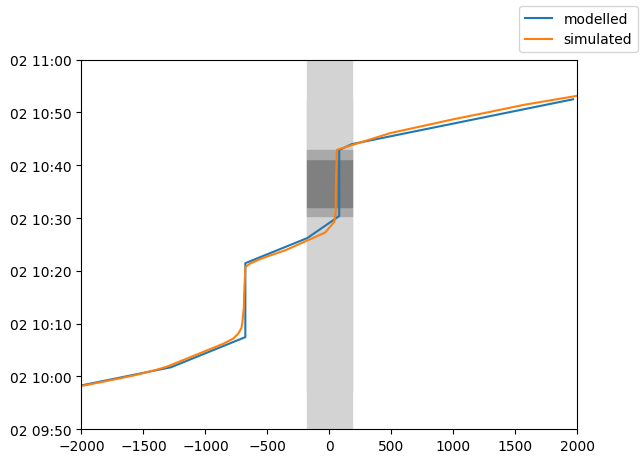

In [10]:
xlimmin = -2000
xlimmax = 2000
ylimmin = pd.Timestamp('2025-09-02 9:50:00')
ylimmax = pd.Timestamp('2025-09-02 11:00:00')

# We can plot the time-distance diagram
fig,ax = plt.subplots()
lock.create_time_distance_plot([vessel_1], xlimmin = xlimmin, xlimmax = xlimmax, ax = ax, label='modelled')
ax.plot(trajectory_gdf.distance_cumulative,trajectory_gdf.index, label='simulated')
ax.set_xlim([xlimmin,xlimmax])
ax.fill([-lock_length/2,-lock_length/2,lock_length/2,lock_length/2],
        [ylimmin,ylimmax,ylimmax,ylimmin],color='lightgrey',zorder=-1)
ax.set_ylim([ylimmin,ylimmax])
fig.legend()
plt.show()

In [11]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 8860743 to node 8862498 start,2025-09-02 09:57:00.000000,0,POINT (4.43615944214078 51.7022764335403)
1,Sailing from node 8860743 to node 8862498 stop,2025-09-02 09:59:16.174771,476.611698,POINT (4.43027504290525 51.7000442261129)
2,Sailing from node 8862498 to node B34113_A start,2025-09-02 09:59:16.174771,476.611698,POINT (4.43027504290525 51.7000442261129)
3,Sailing to waiting area start,2025-09-02 09:59:16.174771,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.43027504290525 51.7000442261129)
4,Sailing to waiting area stop,2025-09-02 10:01:44.580292,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.42400509866192 51.69747197574123)
5,Sailing to waiting area start (with reduced sp...,2025-09-02 10:01:44.580292,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.42400509866192 51.69747197574123)
6,Sailing to waiting area stop (with reduced speed),2025-09-02 10:07:27.437434,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417425659251673 51.69396139614889)
7,Waiting for lock operation start,2025-09-02 10:07:27.437434,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417425659251673 51.69396139614889)
8,Waiting for lock operation stop,2025-09-02 10:21:27.437434,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417425659251673 51.69396139614889)
9,Sailing to first lock doors start,2025-09-02 10:21:27.437434,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417425659251673 51.69396139614889)


In [12]:
lock.operation_planning.iloc[0]

node_from                                                                          8862498
node_to                                                                           B34113_A
direction                                                                                0
lock_chamber                                                                          Lock
vessels                                   [<__main__.Vessel object at 0x000001B4E7866C80>]
capacity_L                                                                      157.101557
capacity_B                                                                       -0.161146
time_potential_lock_door_opening_stop                        2025-09-02 10:16:13.151720164
time_operation_start                                         2025-09-02 10:23:21.723148736
time_entry_start                                             2025-09-02 10:26:13.151720164
time_entry_stop                                              2025-09-02 10:30:23.034443580

In [13]:
lock.vessel_planning.iloc[0]

id                                        25e389d5-78a6-4f58-9190-0094c2affdd6
node_from                                                              8862498
node_to                                                               B34113_A
lock_chamber                                                               NaN
L                                                                          200
B                                                                           30
T                                                                            5
operation_index                                                              0
time_of_registration                                       2025-09-02 09:57:00
time_of_acceptance                                         2025-09-02 09:57:00
time_potential_lock_door_opening_stop            2025-09-02 10:16:13.151720164
time_arrival_at_waiting_area                     2025-09-02 10:07:27.437434450
time_arrival_at_lineup_area                         